# Diabetes - Data Analysis

## 1. Introduction

Diabetes is a health condition that affects how the body controls blood sugar levels, and early detection is important to prevent serious issues. In this project, a diabetes dataset is used to analyze and predict whether a person is diabetic based on medical and personal information. The dataset includes features such as Pregnancies, Glucose, Blood Pressure, Skin Thickness, Insulin, Body Mass Index (BMI), Diabetes Pedigree Function, and Age, while the Outcome column indicates the presence or absence of diabetes. The project focuses on cleaning the data, exploring patterns to understand the factors that are most related to diabetes

## 2. Importing Libraries and Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style = "whitegrid")

In [2]:
df = pd.read_csv("diabetes.csv")
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 3. Data Understanding and Cleaning

In [3]:
print("Data Set Contains", df.shape[0], "rows and ", df.shape[1], " Columns")

Data Set Contains 768 rows and  9  Columns


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
columns_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[columns_with_invalid_zeros] = df[columns_with_invalid_zeros].replace(0, np.nan)

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 4. Exploratory Data Analysis (EDA)

### 4.1. Diabetes Outcomes

Q. Count Diabetes Outcomes.

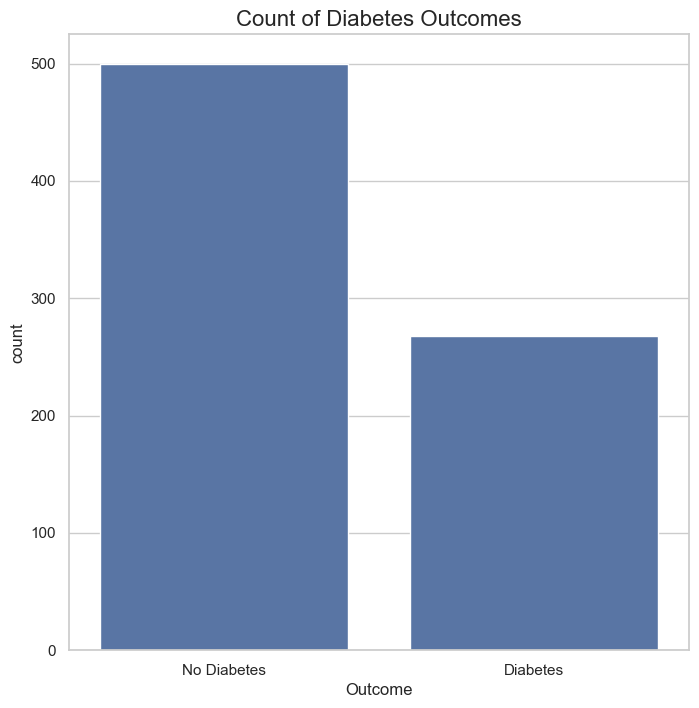

In [8]:
plt.figure(figsize = (8,8))
sns.countplot(x = "Outcome", data = df)
plt.title("Count of Diabetes Outcomes", fontsize = 16)
plt.xticks([0 , 1], ["No Diabetes", "Diabetes"])
plt.show()

This graph shows the count of diabetic and non-diabetic patients in the dataset. It can be observed that the number of people without diabetes is higher than those with diabetes. This visualization helps in understanding the overall distribution

### 4.2. Distribution Of Age

Q. Check the distribution of age.

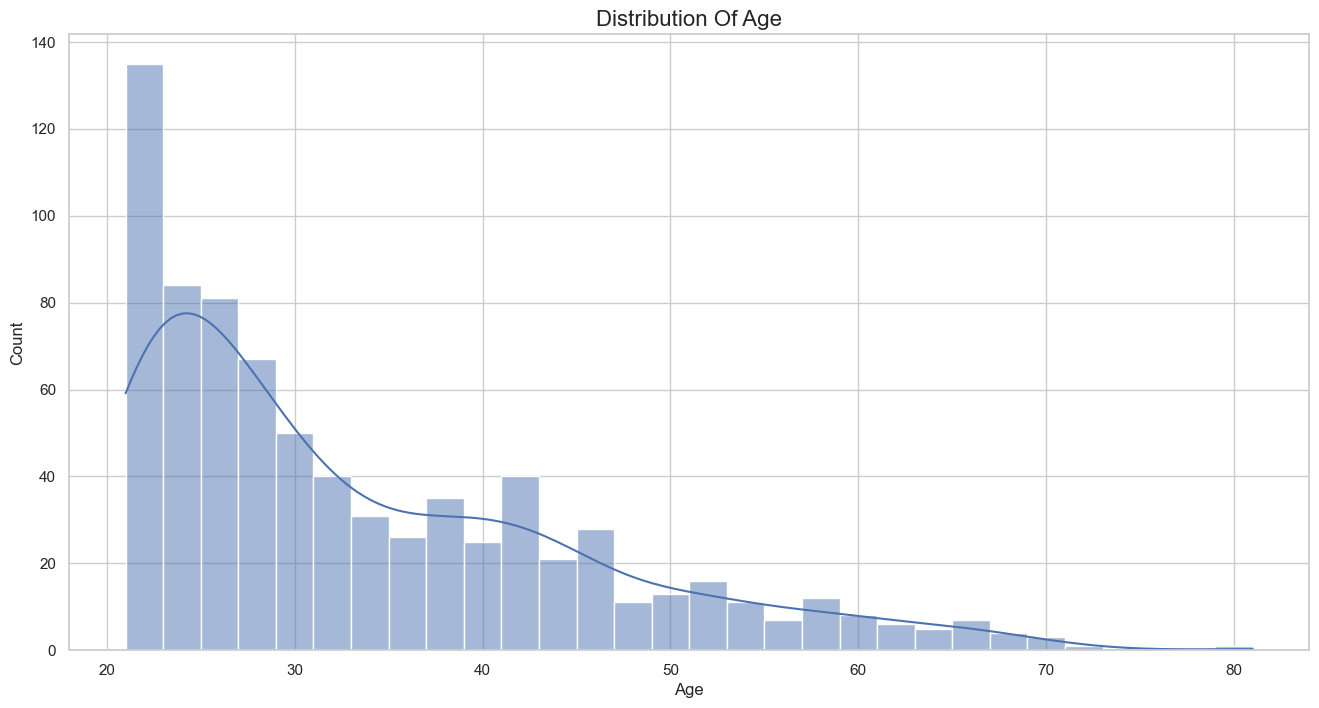

In [9]:
plt.figure(figsize = (16, 8) )
sns.histplot(df["Age"], bins = 30, kde =True)
plt.title("Distribution Of Age", fontsize = 16)
plt.xlabel("Age", fontsize = 12)
plt.show()

This above visualization helps us understand that the dataset contains more younger individuals than older ones, giving insight into the age spread of the patients.

### 4.3. Body Mass Index Distribution

Q. Check BMI distribution

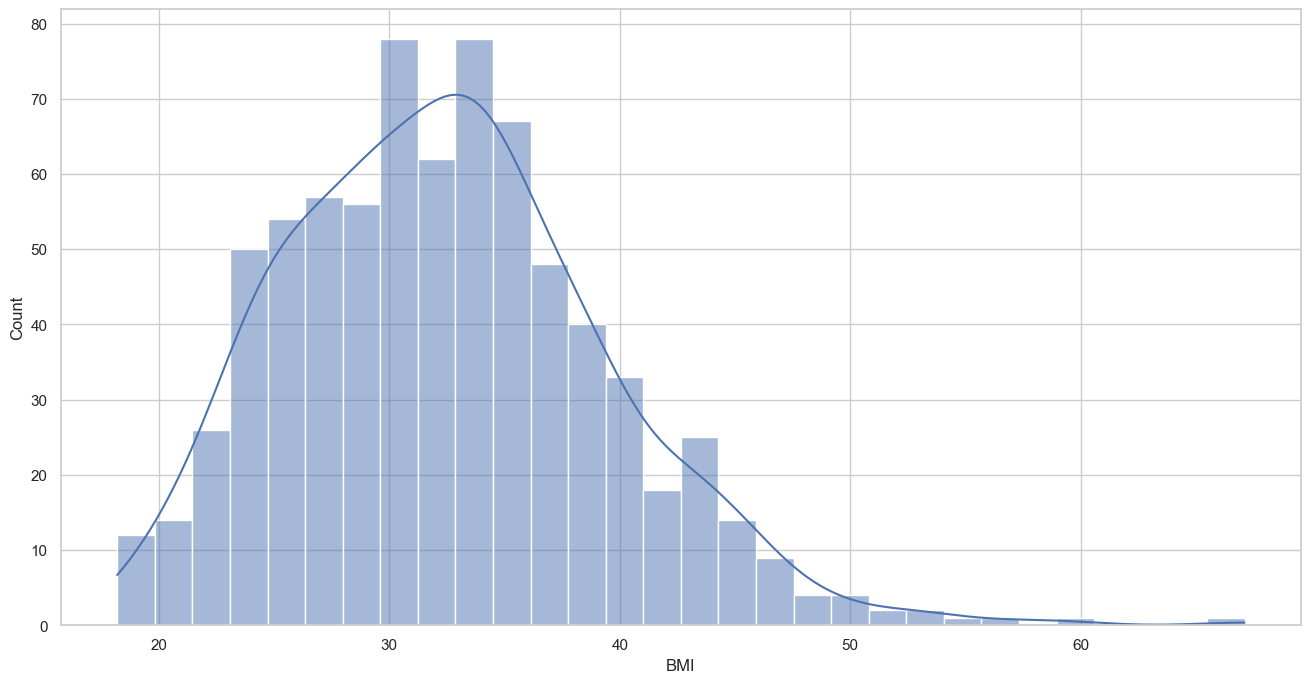

In [10]:
plt.figure( figsize = (16, 8) )
sns.histplot(df["BMI"], bins = 30, kde = True )
plt.xlabel("BMI")
plt.show()

This graph shows how BMI values are distributed in the dataset. Most individuals have BMI values between 25 and 35, while fewer people have very high BMI values. The distribution is slightly right-skewed.

### 4.4. Blood Pressure Distribution

Q. Check the blood pressure distribution

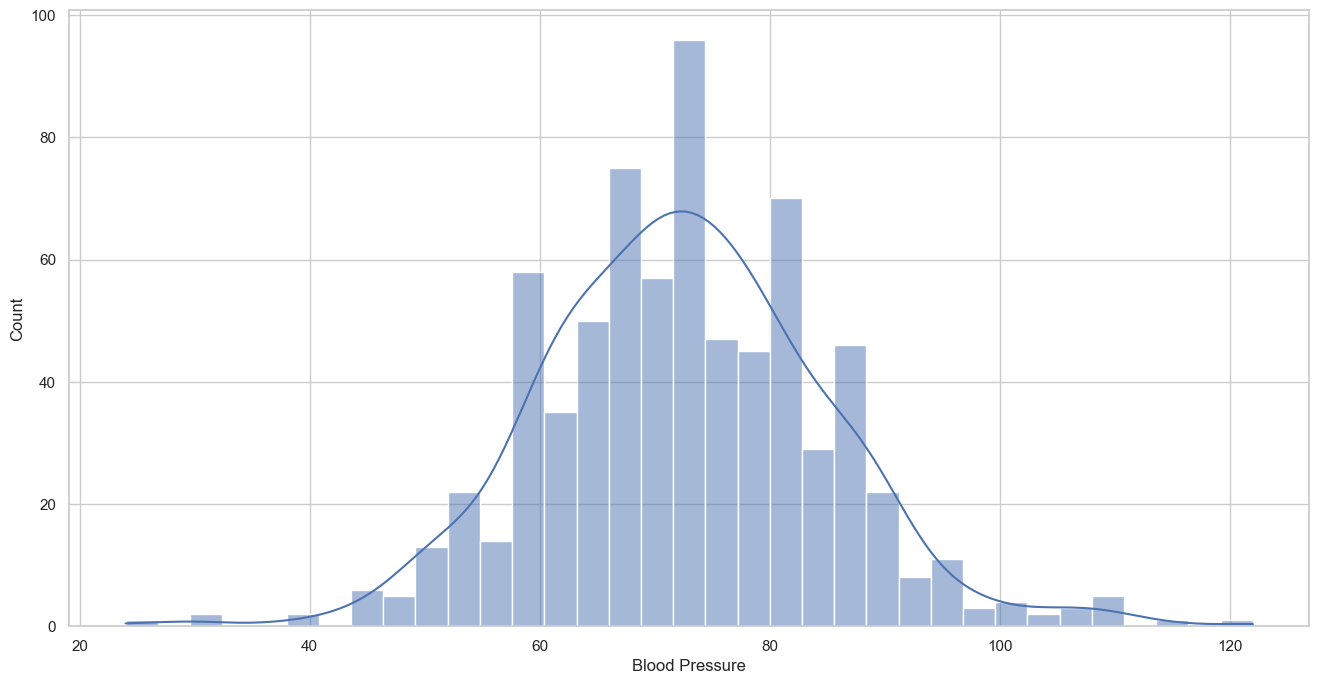

In [11]:
plt.figure(figsize = (16, 8))
sns.histplot(df["BloodPressure"], bins = 35, kde = True )
plt.xlabel("Blood Pressure")
plt.show()

This graph shows how Blood Pressure values are distributed in the dataset. Most individuals have Blood Pressure readings between 60 and 80 mmHg, while fewer people have very low or very high readings

### 4.5. Glucose Distribution

Q. Check the Glucose distribution

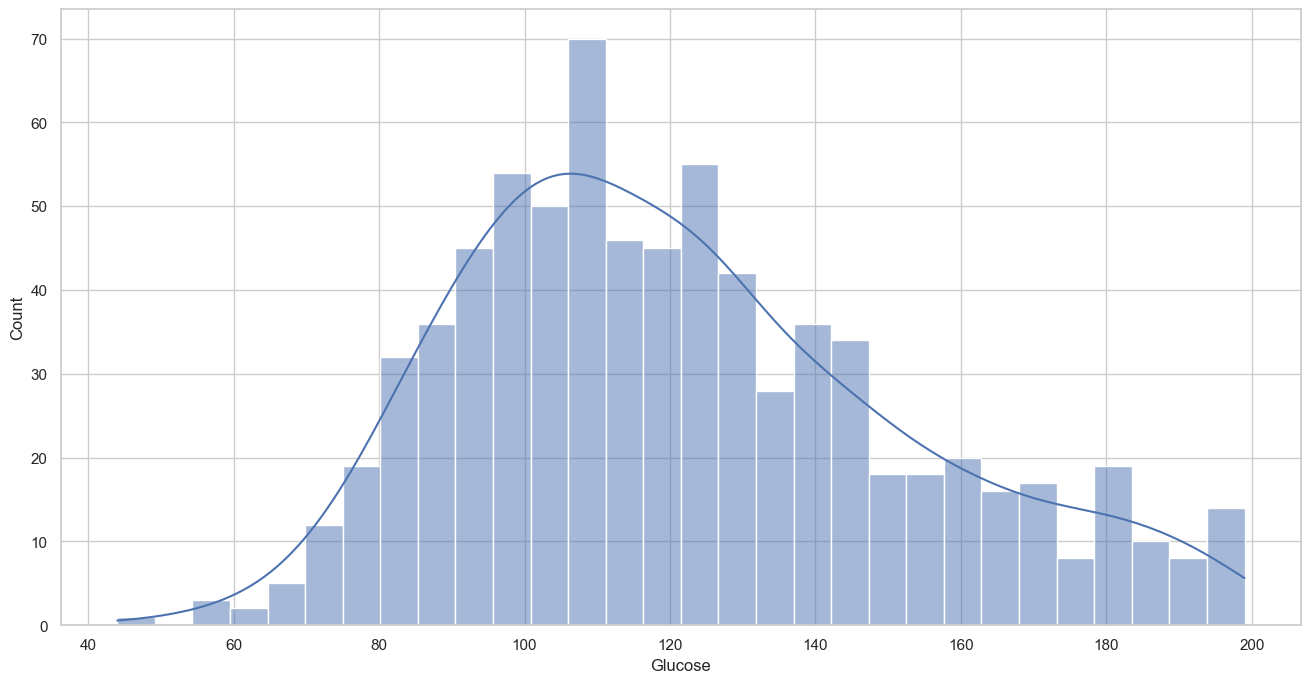

In [12]:
plt.figure(figsize = (16, 8))
sns.histplot(df["Glucose"], bins = 30, kde = True)
plt.xlabel("Glucose")
plt.show()

The glucose shows a slightly right-skewed distribution, with most observations focused between 80 and 140. The spread of the data indicates variability in glucose levels, with fewer observations at higher values.

### 4.6. Glucose Levels by Diabetes Outcome

Q. Check the glucose levels by diabetes outcome

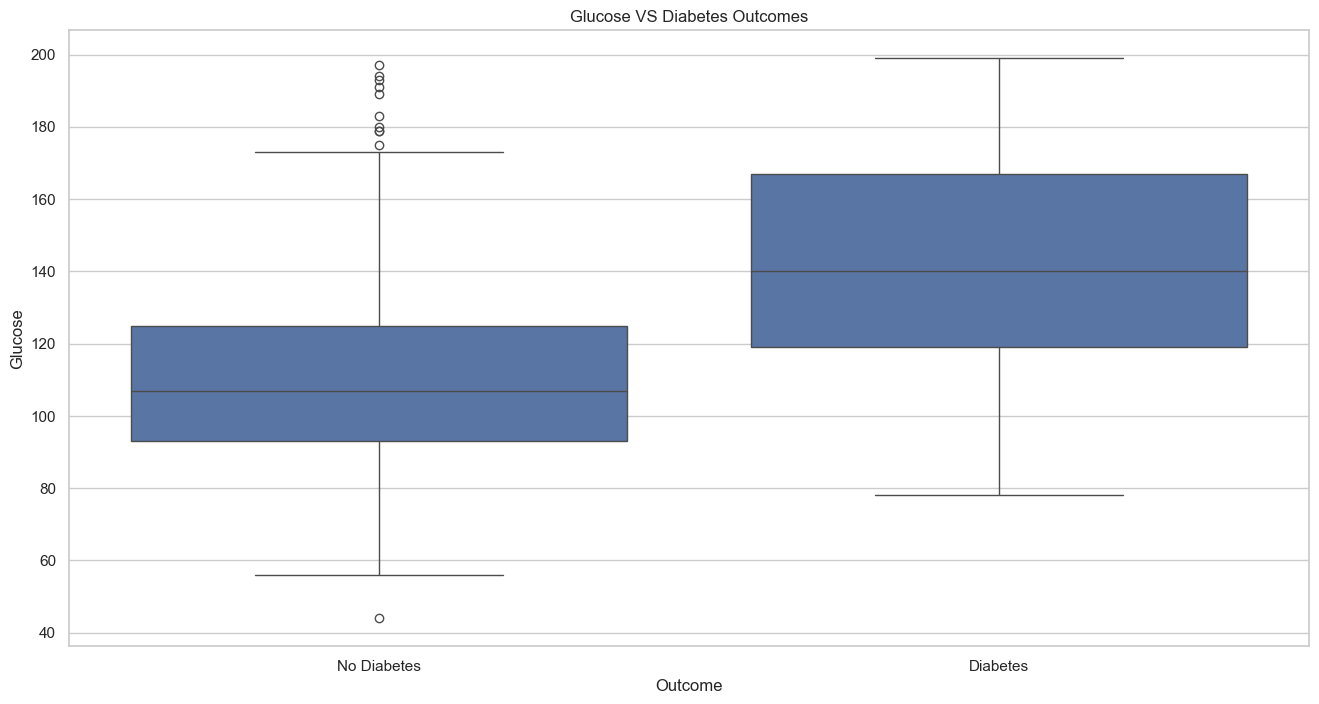

In [13]:
plt.figure( figsize = (16, 8))
sns.boxplot(x = "Outcome", y = "Glucose", data = df)
plt.title("Glucose VS Diabetes Outcomes")
plt.xticks([0 ,1],["No Diabetes", "Diabetes" ])
plt.show()

he boxplot shows that glucose levels are generally higher for individuals with diabetes compared to those without diabetes, with greater variability observed in the diabetic group.

### 4.7. Blood Pressure by Diabetes Outcome

Q. Check the blood pressure by diabetes outcomes

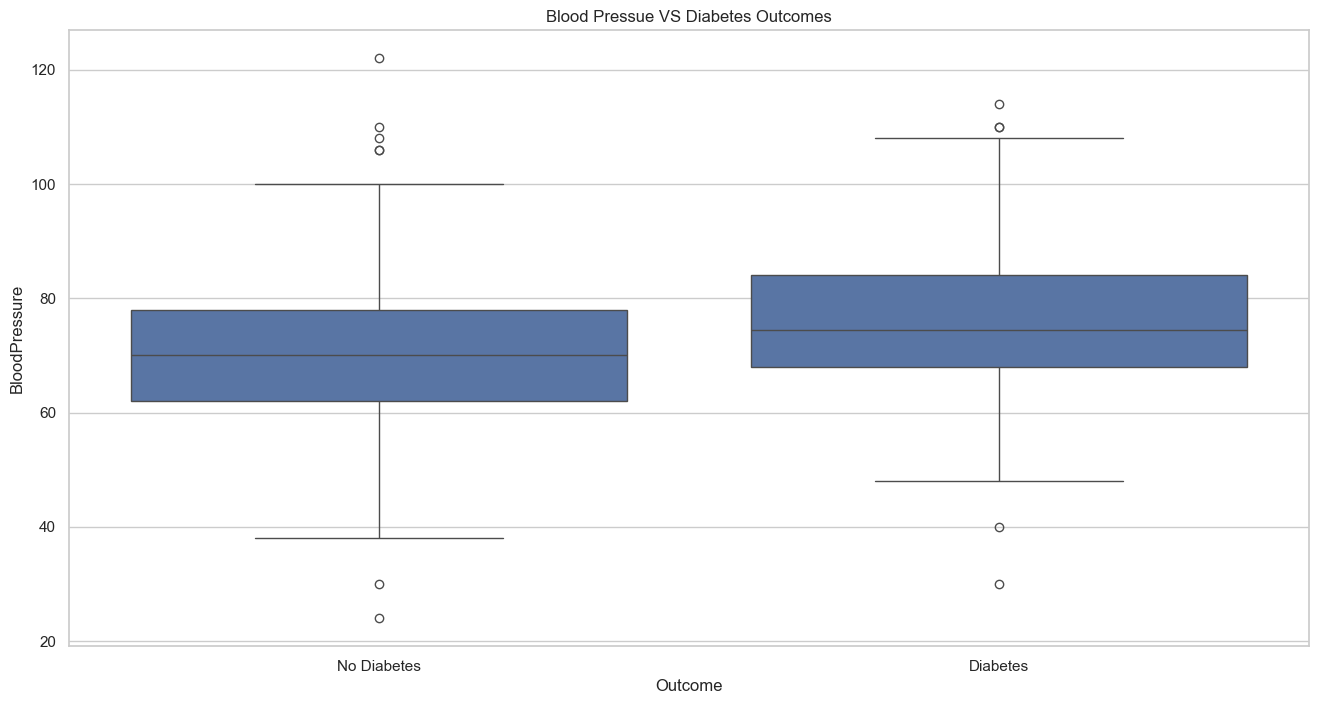

In [14]:
plt.figure( figsize = (16, 8))
sns.boxplot(x = "Outcome", y = "BloodPressure", data = df)
plt.title("Blood Pressue VS Diabetes Outcomes")
plt.xticks([0 ,1], ["No Diabetes", "Diabetes"])
plt.show()

The boxplot shows that individuals with diabetes tend to have slightly higher median blood pressure compared to those without diabetes, with overlapping distributions and the presence of outliers in both groups.

### 4.8. Age Distribution By Diabetes Outcome

Q. Check the age distribution by diabetes outcome

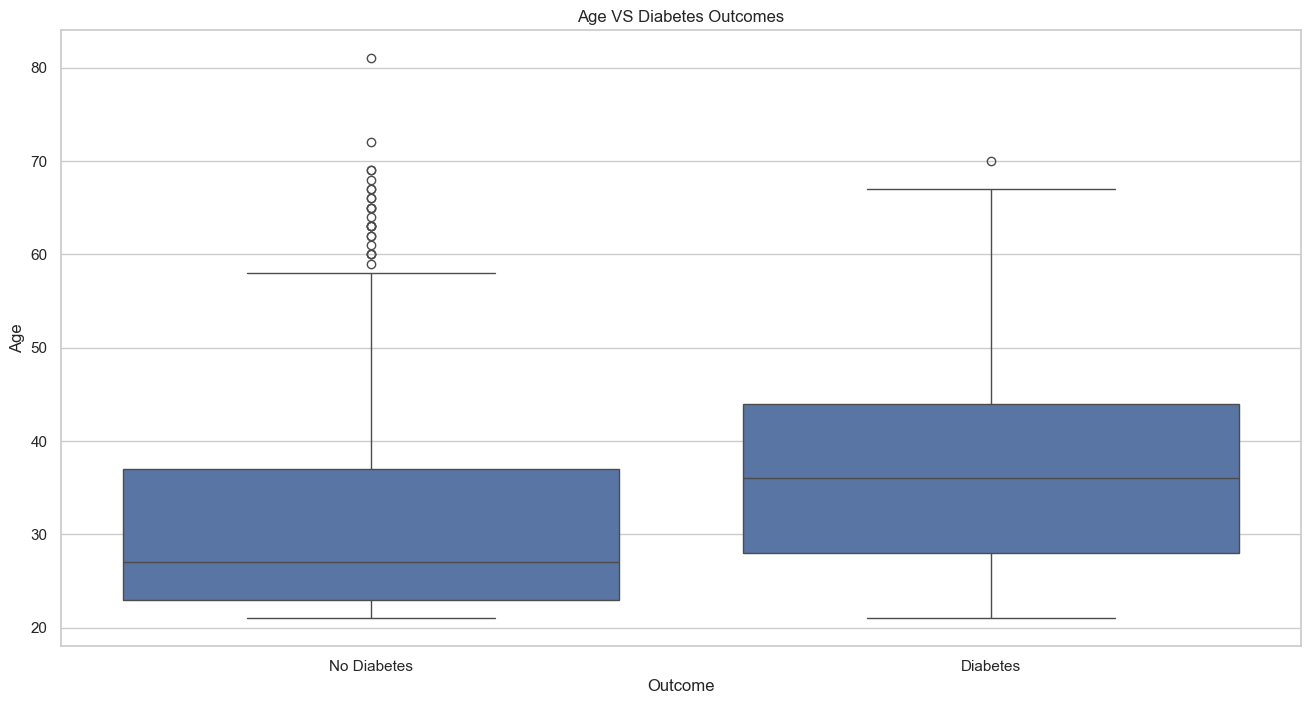

In [15]:
plt.figure( figsize = (16, 8) )
sns.boxplot(x = "Outcome", y = "Age", data = df)
plt.title("Age VS Diabetes Outcomes")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.show()

The 'Diabetes' shows a higher central tendency and greater dispersion in age compared to the 'No Diabetes' group.

### 4.9.Correlation Matrix of Features

Q. What is the correlation between the features and the diabetes outcome?

In [16]:
corr = df.corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128135,0.214178,0.100239,0.082171,0.021719,-0.033523,0.544341,0.221898
Glucose,0.128135,1.000000,0.223192,0.228043,0.581186,0.232771,0.137246,0.267136,0.494650
BloodPressure,0.214178,0.223192,1.000000,0.226839,0.098272,0.289230,-0.002805,0.330107,0.170589
SkinThickness,0.100239,0.228043,0.226839,1.000000,0.184888,0.648214,0.115016,0.166816,0.259491
Insulin,0.082171,0.581186,0.098272,0.184888,1.000000,0.228050,0.130395,0.220261,0.303454
BMI,0.021719,0.232771,0.289230,0.648214,0.228050,1.000000,0.155382,0.025841,0.313680
DiabetesPedigreeFunction,-0.033523,0.137246,-0.002805,0.115016,0.130395,0.155382,1.000000,0.033561,0.173844
Age,0.544341,0.267136,0.330107,0.166816,0.220261,0.025841,0.033561,1.000000,0.238356
Outcome,0.221898,0.494650,0.170589,0.259491,0.303454,0.313680,0.173844,0.238356,1.000000


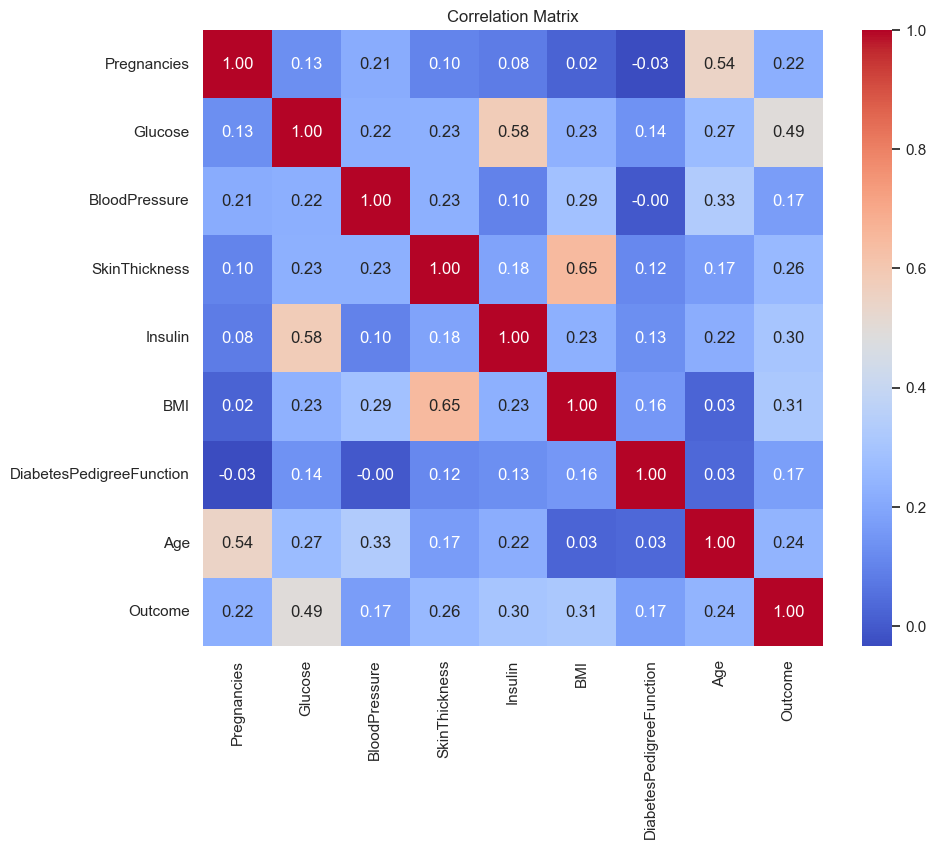

In [17]:
plt.figure( figsize = (10, 8))
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix indicates that glucose has the strongest positive association with the outcome, followed by BMI and insulin

## 5. Key Insights

1. The dataset contains more non-diabetic cases than diabetic cases.
2. Age and BMI distributions are right-skewed, with most individuals in the younger to middle-age and overweight ranges.
3. Diabetic individuals generally show higher glucose levels compared to non-diabetic individuals.
4. Blood pressure shows a slight increase in median values for diabetic individuals.
5. Glucose has the strongest positive correlation with the diabetes outcome, followed by BMI and insulin.

## 6. References

1. Dataset Source:

   Diabetes Dataset, Kaggle: [ https://www.kaggle.com/datasets/shivamb/netflix-shows ]

3. Python Libraries Used:

   a. Numpy
   b. Pandas
   c. Matplotlib
   d. Seaborn